In [1]:
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
import pandas as pd
import shap
import matplotlib.pyplot as plt
import numpy as np
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import MinMaxScaler
shap.initjs()

In [25]:
df = pd.read_csv('diabetes.csv')
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [26]:
df.drop(columns=['DiabetesPedigreeFunction'], inplace=True)

In [4]:
#df.loc[df['BloodPressure'] == 0, 'BloodPressure'] = 50

In [5]:
cols = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'Age']

In [6]:
scaler = MinMaxScaler()
X = pd.DataFrame(scaler.fit_transform(df[cols]), columns=cols)
y = df['Outcome']


In [7]:
lg = LogisticRegression()
lg.fit(X, y)
lg.score(X, y)

0.7630208333333334

In [8]:
explainer = shap.LinearExplainer(model=lg, masker=X)
shap_values = explainer(X)

In [96]:
shap_values

.values =
array([[ 1.99483805e-01,  6.28045432e-01, -3.82927914e-03, ...,
         1.46171646e-03,  9.88328100e-02,  2.84671688e-01],
       [-2.34176640e-01, -9.16931616e-01,  1.28197606e-02, ...,
         1.46171646e-03, -2.44677453e-01, -1.95331530e-02],
       [ 3.72947983e-01,  1.48636601e+00,  1.83694405e-02, ...,
         1.46171646e-03, -4.06618006e-01, -3.52237185e-03],
       ...,
       [ 1.12751716e-01, -3.40875888e-02, -3.82927914e-03, ...,
        -8.95551266e-04, -2.64306611e-01, -3.55439341e-02],
       [-2.34176640e-01,  8.85296372e-02,  2.94688003e-02, ...,
         1.46171646e-03, -7.29223216e-02,  2.36639345e-01],
       [-2.34176640e-01, -7.20744055e-01,  1.72040077e-03, ...,
         1.46171646e-03, -5.82004532e-02, -1.47619402e-01]])

.base_values =
array([-0.77622152, -0.77622152, -0.77622152, -0.77622152, -0.77622152,
       -0.77622152, -0.77622152, -0.77622152, -0.77622152, -0.77622152,
       -0.77622152, -0.77622152, -0.77622152, -0.77622152, -0.77622152,
 

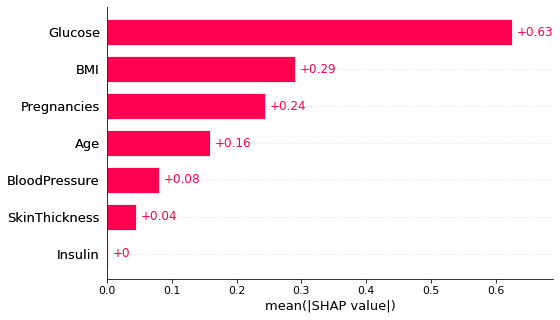

In [9]:
shap.plots.bar(shap_values)

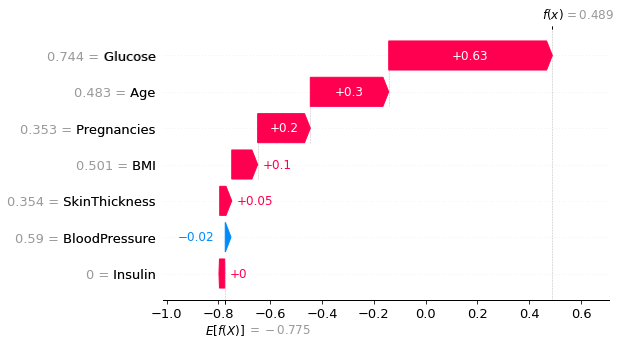

In [10]:
shap.plots.waterfall(shap_values[0])

In [11]:
exp = shap.Explanation(values=shap_values.values, base_values=shap_values.base_values, data=df[cols], display_data = df[cols], feature_names=X.columns)


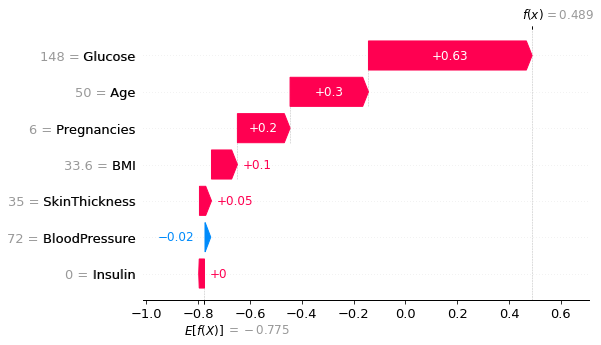

In [12]:
shap.plots.waterfall(exp[0])

In [60]:
X = df.drop(columns='Outcome')
y = df['Outcome']

In [38]:
lg = LogisticRegression(max_iter=5000)
lg.fit(X, y)

LogisticRegression(max_iter=5000)

In [39]:
explainer = shap.LinearExplainer(model=lg, masker=X)
shap_values = explainer(X)

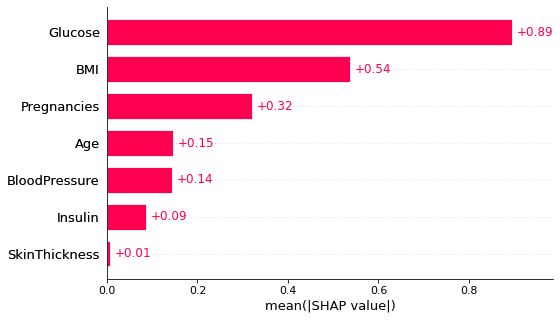

In [40]:
shap.plots.bar(shap_values)

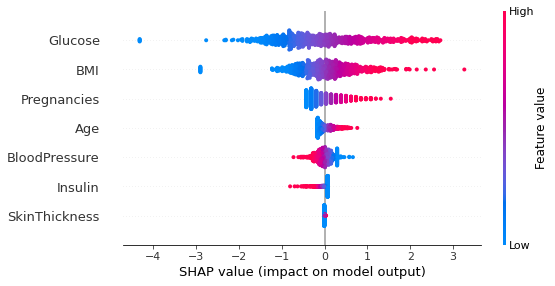

In [41]:
shap.plots.beeswarm(shap_values)

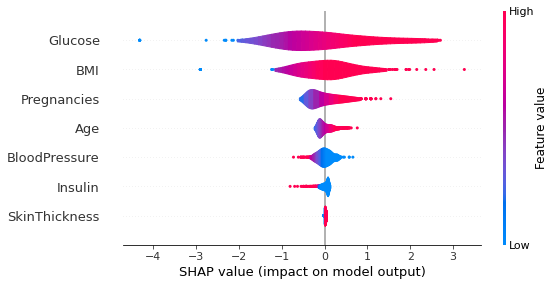

In [42]:
shap.plots.violin(shap_values)

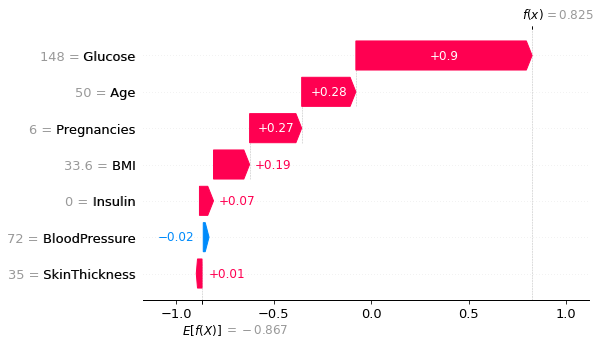

In [43]:
shap.plots.waterfall(shap_values[0])

In [44]:
cols = df.columns[:-1]
df_imp = pd.DataFrame(data = {
    'features': cols,
    'coef': lg.coef_[0],
    'importance': np.abs(lg.coef_[0])
}).sort_values(by='importance', ascending=True)
df_imp[['features', 'coef']]

,features,coef
3,SkinThickness,0.000439
4,Insulin,-0.001038
2,BloodPressure,-0.014153
6,Age,0.015632
1,Glucose,0.035289
5,BMI,0.091869
0,Pregnancies,0.116121


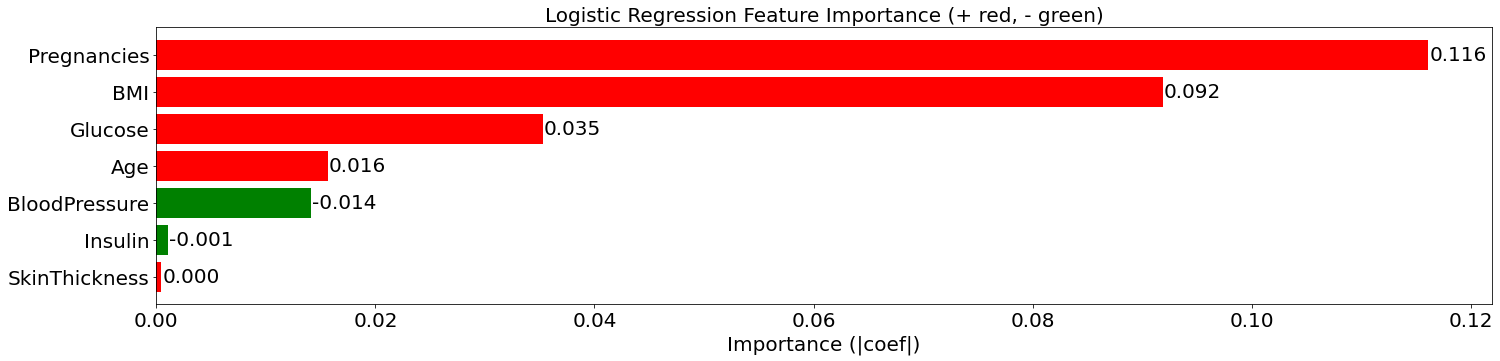

In [45]:
# Lấy hệ số và tên biến
# Màu dựa vào dấu hệ số
colors = ["red" if c > 0 else "green" for c in df_imp['coef']]

plt.figure(figsize=(20,5))
bars = plt.barh(df_imp['features'], df_imp['importance'], color=colors)

# Thêm số lên từng thanh
for bar, coef in zip(bars, df_imp['coef']):
    width = bar.get_width()
    plt.text(width + 0.0001, bar.get_y() + bar.get_height()/2,
             f"{coef:.3f}", va='center', fontsize = 20)

plt.xlabel("Importance (|coef|)", fontsize = 20)
plt.title("Logistic Regression Feature Importance (+ red, - green)", fontsize=20)
plt.tight_layout()
plt.xticks(fontsize = 20)
plt.yticks(fontsize = 20)
plt.show()

In [48]:
cols = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'Age']

In [49]:
scaler = MinMaxScaler()
df[cols] = scaler.fit_transform(df[cols])

In [50]:
X = df[cols]
y = df['Outcome']
lg.fit(X, y)
lg.score(X, y)

0.7669270833333334

In [51]:
cols = df.columns[:-1]
df_imp = pd.DataFrame(data = {
    'features': cols,
    'coef': lg.coef_[0],
    'importance': np.abs(lg.coef_[0])
}).sort_values(by='importance', ascending=True)
df_imp[['features', 'coef']]

,features,coef
4,Insulin,-0.017806
3,SkinThickness,0.213805
2,BloodPressure,-0.271934
6,Age,0.960647
0,Pregnancies,1.474446
5,BMI,3.292791
1,Glucose,4.880166


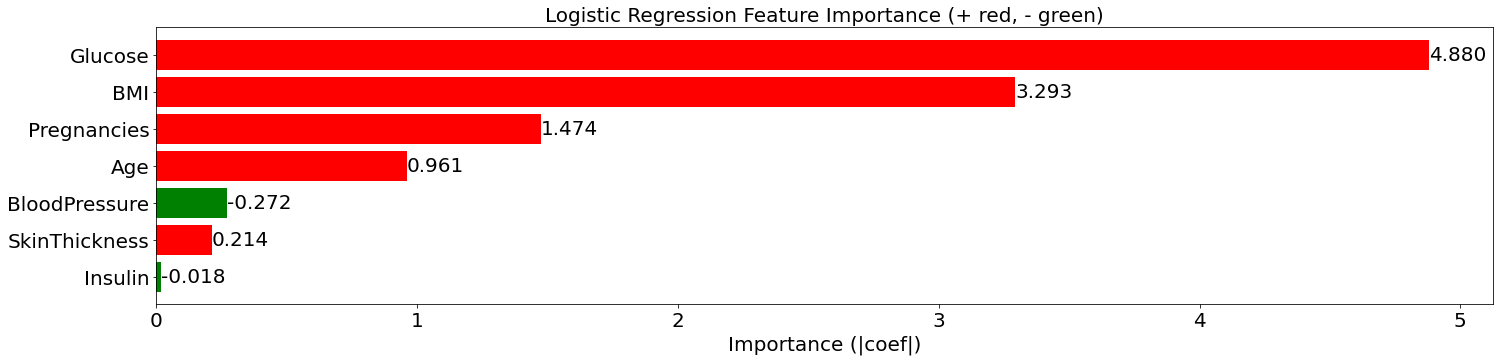

In [52]:
# Lấy hệ số và tên biến
# Màu dựa vào dấu hệ số
colors = ["red" if c > 0 else "green" for c in df_imp['coef']]

plt.figure(figsize=(20,5))
bars = plt.barh(df_imp['features'], df_imp['importance'], color=colors)

# Thêm số lên từng thanh
for bar, coef in zip(bars, df_imp['coef']):
    width = bar.get_width()
    plt.text(width + 0.0001, bar.get_y() + bar.get_height()/2,
             f"{coef:.3f}", va='center', fontsize = 20)

plt.xlabel("Importance (|coef|)", fontsize = 20)
plt.title("Logistic Regression Feature Importance (+ red, - green)", fontsize=20)
plt.tight_layout()
plt.xticks(fontsize = 20)
plt.yticks(fontsize = 20)
plt.show()

In [138]:
data = df.sample(n = 10, random_state = 2026)[['Glucose', 'Age', 'BMI', 'Outcome']]

In [172]:
data.reset_index(drop=True)

,Glucose,Age,BMI,Outcome
0,118,26,44.5,0
1,162,24,37.2,1
2,108,42,32.4,1
3,99,23,22.2,0
4,93,23,38.0,1
5,109,60,36.0,0
6,102,42,39.5,1
7,158,24,31.2,0
8,100,31,46.8,0
9,79,22,25.4,0


In [139]:
data.to_excel('data.xlsx', index=False)

In [186]:
cols = ['Glucose', 'Age', 'BMI']
X = data[cols]
y = data['Outcome']
lg = LogisticRegression(max_iter=1000)
lg.fit(X, y)

LogisticRegression(max_iter=1000)

In [187]:
lg.score(X, y)

0.6

In [188]:
lg.coef_

array([[0.00861909, 0.01090593, 0.04076271]])

In [189]:
df_imp = pd.DataFrame(data = {
    'features': cols,
    'coef': lg.coef_[0],
    'importance': np.abs(lg.coef_[0])
}).sort_values(by='importance', ascending=True)
df_imp[['features', 'coef']]

,features,coef
0,Glucose,0.008619
1,Age,0.010906
2,BMI,0.040763


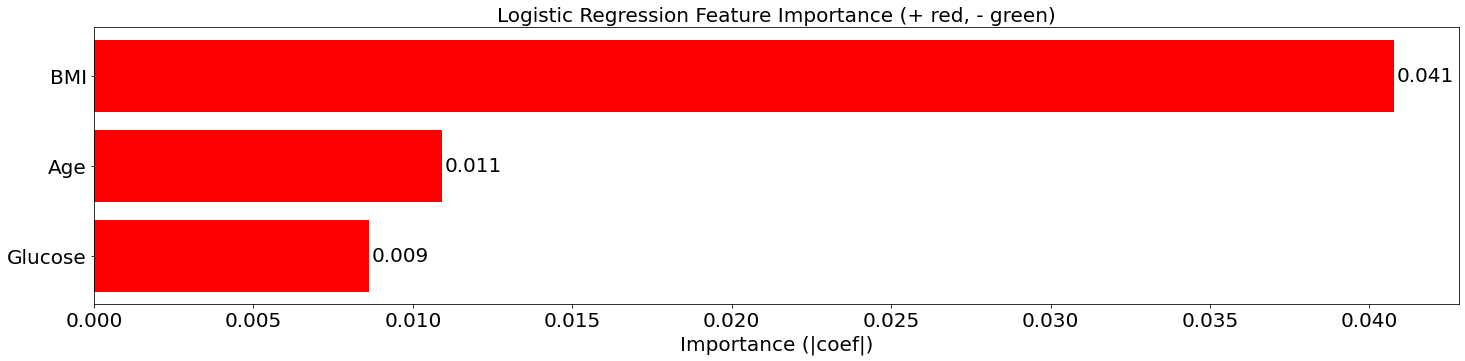

In [190]:
# Lấy hệ số và tên biến
# Màu dựa vào dấu hệ số
colors = ["red" if c > 0 else "green" for c in df_imp['coef']]

plt.figure(figsize=(20,5))
bars = plt.barh(df_imp['features'], df_imp['importance'], color=colors)

# Thêm số lên từng thanh
for bar, coef in zip(bars, df_imp['coef']):
    width = bar.get_width()
    plt.text(width + 0.0001, bar.get_y() + bar.get_height()/2,
             f"{coef:.3f}", va='center', fontsize = 20)

plt.xlabel("Importance (|coef|)", fontsize = 20)
plt.title("Logistic Regression Feature Importance (+ red, - green)", fontsize=20)
plt.tight_layout()
plt.xticks(fontsize = 20)
plt.yticks(fontsize = 20)
plt.show()

In [191]:
explainer = shap.LinearExplainer(model = lg, masker = X)
shap_values = explainer(X)

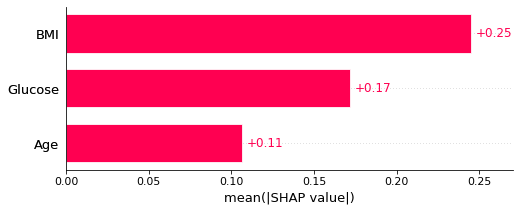

In [209]:
shap.plots.bar(shap_values)

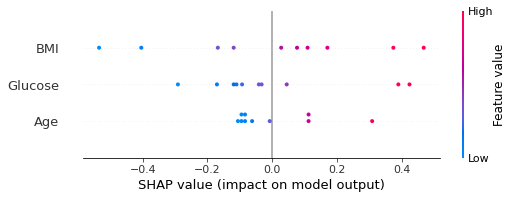

In [211]:
shap.plots.beeswarm(shap_values)

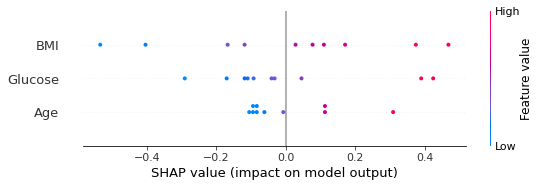

In [192]:
shap.summary_plot(shap_values, feature_names=cols)

In [193]:
help(shap.plots.beeswarm)

Help on function beeswarm in module shap.plots._beeswarm:

beeswarm(shap_values: 'Explanation', max_display: 'int | None' = 10, order=shap.Explanation.abs.mean(0), clustering=None, cluster_threshold=0.5, color=None, axis_color='#333333', alpha: 'float' = 1.0, ax: 'plt.Axes | None' = None, show: 'bool' = True, log_scale: 'bool' = False, color_bar: 'bool' = True, s: 'float' = 16, plot_size: "Literal['auto'] | float | tuple[float, float] | None" = 'auto', color_bar_label: 'str' = 'Feature value', group_remaining_features: 'bool' = True)
    Create a SHAP beeswarm plot, colored by feature values when they are provided.

    Parameters
    ----------
    shap_values : Explanation
        This is an :class:`.Explanation` object containing a matrix of SHAP values
        (# samples x # features).

    max_display : int
        How many top features to include in the plot (default is 10, or 7 for
        interaction plots).

    ax: matplotlib Axes
        Axes object to draw the plot onto, ot

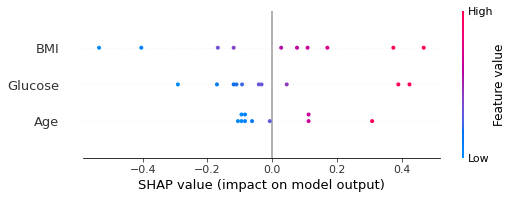

In [194]:
shap.plots.beeswarm(shap_values)

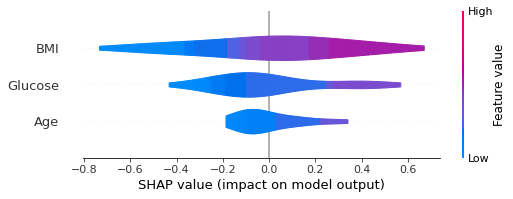

In [195]:
shap.plots.violin(shap_values)

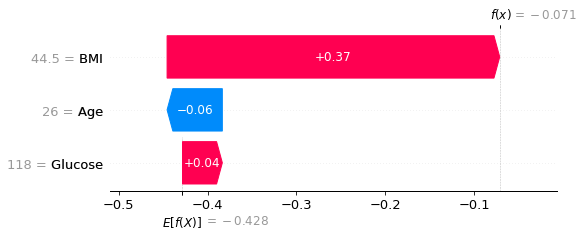

In [196]:
shap.plots.waterfall(shap_values[0])

In [200]:
shap.plots.force(shap_values[0])

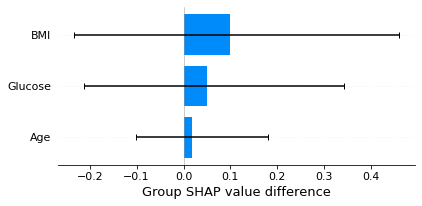

In [207]:
masked = data['Outcome'] == 1
masked = masked.values
shap.plots.group_difference(shap_values = shap_values.values, group_mask = masked, feature_names = cols)

In [202]:
shap_values.values[masked].mean(axis = 0)- shap_values.values[~masked].mean(axis = 0)

array([0.04955978, 0.01908538, 0.09884957])

c:\Users\npchi\.conda\envs\tktmdt\Lib\site-packages\shap\plots\_group_difference.py:42: RuntimeWarning: Mean of empty slice.
  vs.append(shap_values[r].mean(0) - shap_values[~r].mean(0))
c:\Users\npchi\.conda\envs\tktmdt\Lib\site-packages\numpy\core\_methods.py:121: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


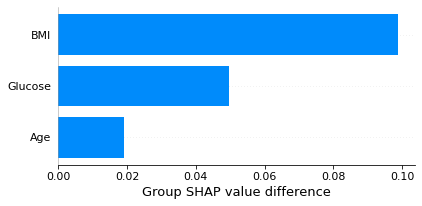

In [163]:
np.mean(X @ lg.coef_.T + lg.intercept_)

-0.42822432489278606

In [164]:
X.mean(axis = 0)  @ lg.coef_.T + lg.intercept_

array([-0.42822432])

In [166]:
Xt = X - X.mean(axis = 0)
lg.coef_ * Xt + lg.intercept_

array([[-3.14109557, -3.24807867, -2.81171318],
       [-2.76185553, -3.26989054, -3.10928096],
       [-3.22728649, -3.07358374, -3.30494196],
       [-3.30485832, -3.28079647, -3.7207216 ],
       [-3.35657287, -3.28079647, -3.07667079],
       [-3.2186674 , -2.87727695, -3.15819621],
       [-3.27900104, -3.07358374, -3.01552673],
       [-2.7963319 , -3.26989054, -3.35385721],
       [-3.29623923, -3.193549  , -2.71795895],
       [-3.47724016, -3.2917024 , -3.59028093]])

In [169]:
lg.coef_ * (X - X.mean(axis = 0))

array([[ 0.04481928, -0.06216382,  0.37420167],
       [ 0.42405932, -0.08397568,  0.07663389],
       [-0.04137164,  0.11233111, -0.11902711],
       [-0.11894347, -0.09488162, -0.53480675],
       [-0.17065802, -0.09488162,  0.10924406],
       [-0.03275255,  0.3086379 ,  0.02771864],
       [-0.09308619,  0.11233111,  0.17038812],
       [ 0.38958295, -0.08397568, -0.16794236],
       [-0.11032438, -0.00763415,  0.4679559 ],
       [-0.2913253 , -0.10578755, -0.40436608]])

In [167]:
shap_values.values

array([[ 0.04481928, -0.06216382,  0.37420167],
       [ 0.42405932, -0.08397568,  0.07663389],
       [-0.04137164,  0.11233111, -0.11902711],
       [-0.11894347, -0.09488162, -0.53480675],
       [-0.17065802, -0.09488162,  0.10924406],
       [-0.03275255,  0.3086379 ,  0.02771864],
       [-0.09308619,  0.11233111,  0.17038812],
       [ 0.38958295, -0.08397568, -0.16794236],
       [-0.11032438, -0.00763415,  0.4679559 ],
       [-0.2913253 , -0.10578755, -0.40436608]])

In [117]:
lg.predict_proba(X)

array([[0.33912623, 0.66087377],
       [0.92587406, 0.07412594],
       [0.39601205, 0.60398795],
       ...,
       [0.80492174, 0.19507826],
       [0.60444745, 0.39555255],
       [0.89990178, 0.10009822]])

In [152]:
shap_values.values

array([[ 0.04481916, -0.06216359,  0.37420148],
       [ 0.42405819, -0.08397538,  0.07663385],
       [-0.04137153,  0.1123307 , -0.11902705],
       [-0.11894315, -0.09488127, -0.53480648],
       [-0.17065756, -0.09488127,  0.10924401],
       [-0.03275246,  0.30863679,  0.02771863],
       [-0.09308594,  0.1123307 ,  0.17038804],
       [ 0.38958191, -0.08397538, -0.16794228],
       [-0.11032408, -0.00763413,  0.46795567],
       [-0.29132453, -0.10578717, -0.40436587]])

In [104]:
lg.coef_, lg.intercept_

(array([[0.03251144, 0.03015405, 0.08157363]]), array([-8.39307912]))

In [52]:
mlp = MLPClassifier(max_iter=5000, hidden_layer_sizes=(20,), random_state=2026)
mlp.fit(X, y)
mlp.score(X, y)

0.9

In [7]:
mlp.predict_proba(X)[:,1]

array([0.36346515, 0.73704693, 0.98636361, 0.00293762, 0.39663878,
       0.01125218, 0.99308852, 0.29772359, 0.09257466, 0.00609566])

In [71]:
mlp.predict_proba(X)[:].mean(axis=0)

array([0.61128133, 0.38871867])

In [53]:
mlp.predict(X)

array([1, 1, 1, 0, 1, 0, 0, 1, 0, 0], dtype=int64)

In [16]:
mask = np.array([
    [0, 0, 0],
    [0, 0, 1],
    [0, 1, 0],
    [0, 1, 1],
    [1, 0, 0],
    [1, 0, 1],
    [1, 1, 0],
    [1, 1, 1]
])

In [11]:
avg = X.mean(axis=0)

In [9]:
def replace(val, avg):
    if val == 0:
        return avg
    return val

In [45]:
arr = X[:1] * mask
arr = arr.tolist()
for i in range(len(arr)):
    for j in range(len(arr[i])):
        arr[i][j] = replace(arr[i][j], avg[j])
Xt = np.array(arr)
Xt

array([[112.8,  31.7,  63.3],
       [112.8,  31.7,  70. ],
       [112.8,  26. ,  63.3],
       [112.8,  26. ,  70. ],
       [118. ,  31.7,  63.3],
       [118. ,  31.7,  70. ],
       [118. ,  26. ,  63.3],
       [118. ,  26. ,  70. ]])

In [46]:
results = mlp.predict_proba(Xt)[:, 1]
results


array([0.93893299, 0.83750893, 0.64479937, 0.376747  , 0.93491251,
       0.82933083, 0.62906426, 0.36346515])

In [47]:
Xt = X - X.mean(axis=0)
results = mlp.predict_proba(Xt[:1] * mask)[:,1]
results

array([0.82921506, 0.9362408 , 0.69636865, 0.42753235, 0.84628392,
       0.75475183, 0.74009986, 0.1466167 ])

In [44]:
results[-1] - results[0]

-0.68259835919306

In [34]:
np.expand_dims(X.mean(axis=0), 0)


array([[112.8,  31.7,  63.3]])

In [35]:
mlp.predict_proba(np.expand_dims(X.mean(axis=0), 0))

array([[0.06106701, 0.93893299]])

In [19]:
mlp.predict_proba(X[:1])

array([[0.63653485, 0.36346515]])

In [78]:
mlp.predict_proba(mask * X[0])


array([[1.70784938e-01, 8.29215062e-01],
       [1.80973473e-06, 9.99998190e-01],
       [9.99999999e-01, 6.36883066e-10],
       [2.42939002e-12, 1.00000000e+00],
       [5.71000288e-01, 4.28999712e-01],
       [9.99996655e-01, 3.34541583e-06],
       [9.98193049e-01, 1.80695105e-03],
       [6.36534846e-01, 3.63465154e-01]])

In [199]:
explainer = shap.KernelExplainer(model=lambda x: mlp.predict_proba(x), data=X, feature_names=cols)
shap_values = explainer(X)

Provided model function fails when applied to the provided data set.


NameError: name 'mlp' is not defined

In [16]:
shap_values.values[:,:, 1]

array([[ 0.01335455, -0.04056959,  0.00196152],
       [ 0.0113826 , -0.07477277,  0.41171843],
       [ 0.02671888,  0.48094781,  0.08997824],
       [-0.05075629, -0.09323666, -0.2417881 ],
       [ 0.04087503, -0.17823569,  0.14528076],
       [-0.04516802, -0.31369341, -0.01860506],
       [ 0.01043966,  0.56323726,  0.03069293],
       [-0.00778447, -0.16828266,  0.08507204],
       [-0.0073935 ,  0.0678566 , -0.35660712],
       [ 0.00833153, -0.24325089, -0.14770365]])

In [23]:
shap_values.base_values[0]

array([0.61128133, 0.38871867])

In [29]:
np.expand_dims(X.values.mean(axis=0), 0)

array([[112.8,  31.7,  63.3]])

In [30]:
mlp.predict_proba(np.expand_dims(X.values.mean(axis=0), 0))

array([[0.34755046, 0.65244954]])

In [28]:
shap_values.base_values

array([[0.61128133, 0.38871867],
       [0.61128133, 0.38871867],
       [0.61128133, 0.38871867],
       [0.61128133, 0.38871867],
       [0.61128133, 0.38871867],
       [0.61128133, 0.38871867],
       [0.61128133, 0.38871867],
       [0.61128133, 0.38871867],
       [0.61128133, 0.38871867],
       [0.61128133, 0.38871867]])

In [29]:
shap_values.values[:,:,1]

array([[ 0.01335455, -0.04056959,  0.00196152],
       [ 0.0113826 , -0.07477277,  0.41171843],
       [ 0.02671888,  0.48094781,  0.08997824],
       [-0.05075629, -0.09323666, -0.2417881 ],
       [ 0.04087503, -0.17823569,  0.14528076],
       [-0.04516802, -0.31369341, -0.01860506],
       [ 0.01043966,  0.56323726,  0.03069293],
       [-0.00778447, -0.16828266,  0.08507204],
       [-0.0073935 ,  0.0678566 , -0.35660712],
       [ 0.00833153, -0.24325089, -0.14770365]])

In [21]:
mlp.predict_proba(X.values).mean(axis=0)

array([0.60121068, 0.39878932])

In [76]:
shap_values.values[:,:, 1]

array([[ 0.01335455, -0.04056959,  0.00196152],
       [ 0.0113826 , -0.07477277,  0.41171843],
       [ 0.02671888,  0.48094781,  0.08997824],
       [-0.05075629, -0.09323666, -0.2417881 ],
       [ 0.04087503, -0.17823569,  0.14528076],
       [-0.04516802, -0.31369341, -0.01860506],
       [ 0.01043966,  0.56323726,  0.03069293],
       [-0.00778447, -0.16828266,  0.08507204],
       [-0.0073935 ,  0.0678566 , -0.35660712],
       [ 0.00833153, -0.24325089, -0.14770365]])

In [41]:
X[0]

array([118,  26,  70], dtype=int64)

In [37]:
dtc = DecisionTreeClassifier(max_depth = 3, random_state = 42)
dtc.fit(X, y)
dtc.score(X, y)

0.9

In [38]:
dtc.predict_proba(X)

array([[0.75, 0.25],
       [0.75, 0.25],
       [0.  , 1.  ],
       [0.75, 0.25],
       [0.  , 1.  ],
       [1.  , 0.  ],
       [0.  , 1.  ],
       [0.75, 0.25],
       [1.  , 0.  ],
       [1.  , 0.  ]])

In [66]:
data['Outcome'].value_counts(normalize=True)

Outcome
0    0.6
1    0.4
Name: proportion, dtype: float64

In [148]:
cols = ['Glucose', 'BloodPressure', 'Age']
data = df[cols + ['Outcome']].sample(n = 10, random_state=2026)
X = data[cols]
y = data['Outcome']

In [149]:
dtc = DecisionTreeClassifier(max_depth=3, random_state=2026)
dtc.fit(X, y)
dtc.score(X, y)

0.9

In [151]:
print(export_text(dtc, feature_names=cols))

|--- BloodPressure <= 74.50
|   |--- Age <= 34.00
|   |   |--- Glucose <= 96.00
|   |   |   |--- class: 1
|   |   |--- Glucose >  96.00
|   |   |   |--- class: 0
|   |--- Age >  34.00
|   |   |--- class: 1
|--- BloodPressure >  74.50
|   |--- class: 0



In [154]:
print(dtc.tree_.n_node_samples)
print(dtc.tree_.value.reshape(-1,2))

[10  7  5  1  4  2  3]
[[0.6        0.4       ]
 [0.42857143 0.57142857]
 [0.6        0.4       ]
 [0.         1.        ]
 [0.75       0.25      ]
 [0.         1.        ]
 [1.         0.        ]]


In [117]:
data

,Glucose,BloodPressure,Age,Outcome
699,118,70,26,0
227,162,52,24,1
143,108,66,42,1
430,99,0,23,0
709,93,64,23,1
30,109,75,60,0
739,102,74,42,1
710,158,64,24,0
57,100,88,31,0
232,79,80,22,0


In [94]:
data.to_csv('tree.csv', index=False)

In [118]:
explainer = shap.TreeExplainer(model = dtc, data = X, feature_names=cols)
shap_values = explainer(X = X)
shap_values.values[:,:, 1]

array([[-0.1125,  0.15  , -0.1875],
       [-0.1125,  0.15  , -0.1875],
       [-0.05  ,  0.25  ,  0.4   ],
       [-0.1125,  0.15  , -0.1875],
       [ 0.4375,  0.25  , -0.0875],
       [-0.025 , -0.5375,  0.1625],
       [-0.05  ,  0.25  ,  0.4   ],
       [-0.1125,  0.15  , -0.1875],
       [-0.0375, -0.2875, -0.075 ],
       [ 0.175 , -0.525 , -0.05  ]])

In [119]:
Xt = np.array([
    [119, 26, 71]
])
explainer(Xt).values[:,:,1]

array([[-0.05,  0.25,  0.4 ]])

In [120]:
shap_values.base_values

array([[0.6, 0.4],
       [0.6, 0.4],
       [0.6, 0.4],
       [0.6, 0.4],
       [0.6, 0.4],
       [0.6, 0.4],
       [0.6, 0.4],
       [0.6, 0.4],
       [0.6, 0.4],
       [0.6, 0.4]])

$$ BP = 0.48 - \frac{7}{10} * 0.49 - \frac{3}{10} * 0 = 0.137 $$
$$ Age = 0.49 - \frac{5}{7} * 0.48 - \frac{2}{7} * 0 = 0.147 $$
$$ Glucose = 0.48 - \frac{1}{5} * 0 - \frac{4}{5} * 0.375 = 0.18 $$

$$ (BP, \frac{7}{10} * Age, \frac{5}{10} * Glucose) = (0.137, 0.103, 0.09) $$

In [158]:
arr = np.array([0.48 - 7 / 10 * 0.49, 0.49 - 5 / 7 * 0.48, 0.48 - 4/5 * 0.375])
brr = [1, 7/ 10, 5 / 10]
arr = np.array([u* v for u, v in zip(arr, brr)])
arr, arr / arr.sum()

(array([0.137, 0.103, 0.09 ]), array([0.41515152, 0.31212121, 0.27272727]))

$$ (BP = 0.41, Age = 0.31, Glucose = 0.27) $$

In [162]:
4 / 7 - 4 / 10, 2 / 5 - 4 / 7, 1 / 4 - 2 / 5 

(0.17142857142857137, -0.17142857142857137, -0.15000000000000002)

$$ \text{base value} = \frac{4}{10} = 0.4 $$
$$ \phi_{BP} = \frac{4}{7} - \frac{4}{10} = 0.171 $$
$$ \phi_{Age} = \frac{2}{5} - \frac{4}{7} = -0.171 $$
$$ \phi_{Glucose} = \frac{1}{4} - \frac{2}{5} = -0.15 $$

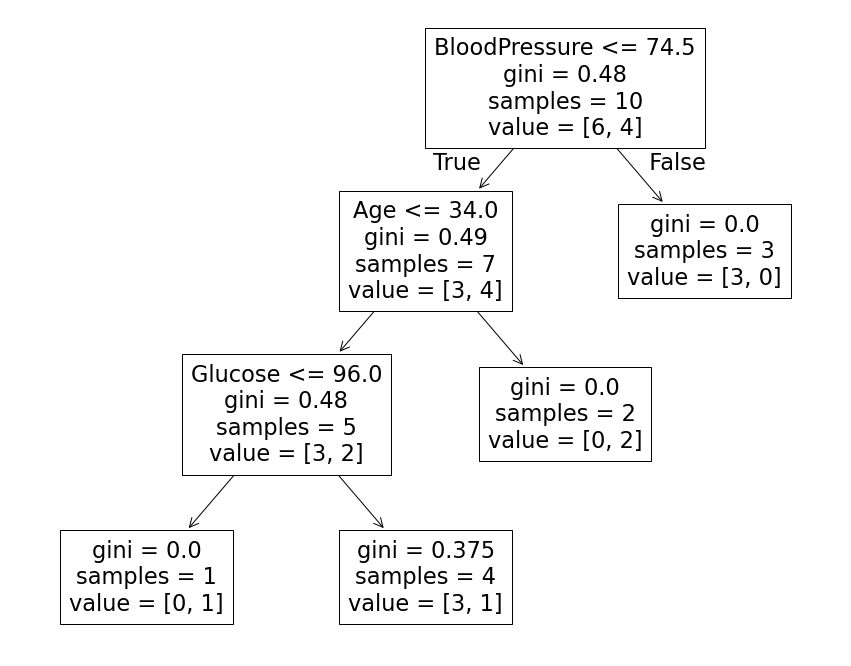

In [121]:
plt.figure(figsize=(15, 12))
plot_tree(decision_tree=dtc, feature_names=cols)
plt.show()

In [137]:
bp = (4 / 7 - 4 / 10)

In [138]:
age = (2 / 5 - 4 / 7)

In [140]:
glu = (1 / 4 - 2 / 5)
print([bp, age, glu], sum([bp, age, glu]) + 0.4)

[0.17142857142857137, -0.17142857142857137, -0.15000000000000002] 0.25


In [134]:

0.4 + sum([1/3 * bp, 1/6 * age, 1/3 * glu])

0.4023809523809524

In [98]:
dtc.feature_names_in_

array(['Glucose', 'BloodPressure', 'Age'], dtype=object)

In [122]:
expaliner = shap.TreeExplainer(model = dtc, data = X)
shap_values = explainer(X)

In [146]:
shap_values.values[0, :, 1]

array([-0.1125,  0.15  , -0.1875])

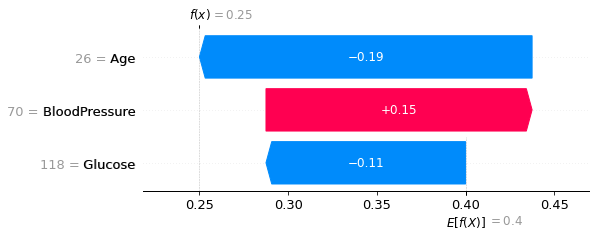

In [147]:
shap.plots.waterfall(shap_values[0, :, 1])

In [123]:
sum(shap_values.values[:,:,1][0]) +  shap_values.base_values[0][1]

0.25

In [124]:
dtc.predict_proba(X)

array([[0.75, 0.25],
       [0.75, 0.25],
       [0.  , 1.  ],
       [0.75, 0.25],
       [0.  , 1.  ],
       [1.  , 0.  ],
       [0.  , 1.  ],
       [0.75, 0.25],
       [1.  , 0.  ],
       [1.  , 0.  ]])

In [58]:
print(export_text(dtc, feature_names=cols))

|--- BloodPressure <= 74.50
|   |--- Age <= 34.00
|   |   |--- Glucose <= 96.00
|   |   |   |--- class: 1
|   |   |--- Glucose >  96.00
|   |   |   |--- class: 0
|   |--- Age >  34.00
|   |   |--- class: 1
|--- BloodPressure >  74.50
|   |--- class: 0



In [61]:
trr = np.array([(5 / 10) * (0.48 - 4 / 5 * 0.375), 0.48 - 7 / 10 * 0.49, 7/10 * (0.49 - 0.48 * 5 / 7)])
trr

array([0.09 , 0.137, 0.103])

In [62]:
trr / sum(trr)


array([0.27272727, 0.41515152, 0.31212121])

In [50]:
dtc.feature_importances_, dtc.feature_names_in_

(array([0.27272727, 0.41558442, 0.31168831]),
 array(['Glucose', 'BloodPressure', 'Age'], dtype=object))

In [130]:
(4 / 7 - 4 / 10) * (1/3)

0.05714285714285712

In [63]:
dtc = DecisionTreeClassifier(random_state=2026)
dtc.fit(X, y)
dtc.score(X, y)

1.0

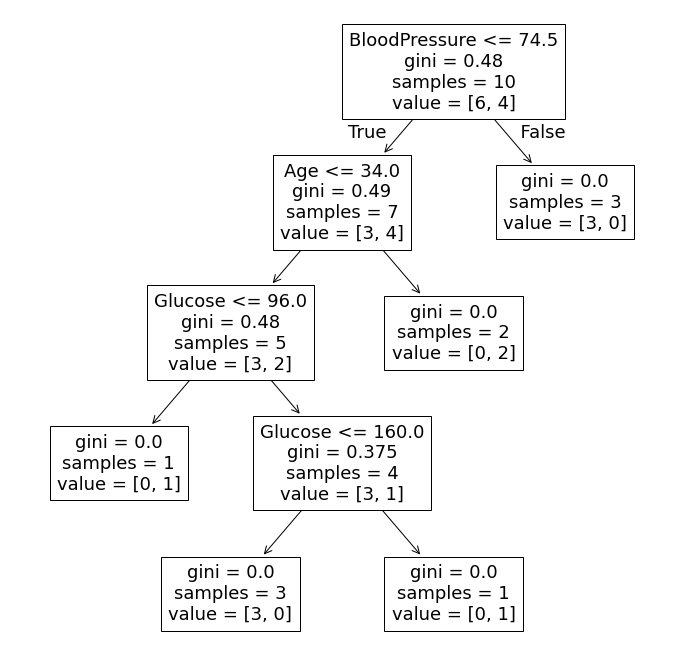

In [82]:
plt.figure(figsize=(12, 12))
plot_tree(dtc, feature_names=cols)
plt.show()

In [80]:
bp = 0.48 - 7 / 10 * 0.49
bp

0.137

In [84]:
age = 0.49 - 0.48 * 5 / 7
age

0.14714285714285713

In [88]:
glucose1 = 0.48 - 0.375 * 4 / 5
glucose2 = 0.375


In [92]:
xrr = np.array([glucose1 * 5 / 10 + glucose2 * 4 / 10, bp, age * 7 / 10])
xrr, xrr / xrr.sum()

(array([0.24 , 0.137, 0.103]), array([0.5       , 0.28541667, 0.21458333]))

In [77]:
dtc.feature_importances_, dtc.feature_names_in_

(array([0.5       , 0.28571429, 0.21428571]),
 array(['Glucose', 'BloodPressure', 'Age'], dtype=object))